In [ ]:
import sys

sys.path.append("..")

from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import cartopy.crs as crs
import cartopy.feature as cfeature
from shapely.geometry import Point
import shapely.vectorized as sv
from statistics import mean

from src.data import nysm_data
from src.data import hrrr_data

from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

from matplotlib.colors import LogNorm
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm

import traceback
from matplotlib import colors

In [ ]:
hs = "QUEE"
chosen_cmap = "hot_r"
vmin1 = 30
vmax1 = 40

In [ ]:
def date_filter(ldf, time1, time2):
    ldf = ldf[ldf["valid_time"] > time1]
    ldf = ldf[ldf["valid_time"] < time2]

    return ldf


def idw_interpolation(x, y, z, xi, yi, power=2):
    """
    x, y = known points
    z = values
    xi, yi = meshgrid of where to interpolate
    """
    dist = np.sqrt((xi[..., None] - x) ** 2 + (yi[..., None] - y) ** 2)

    # Avoid division by zero
    dist = np.where(dist == 0, 1e-12, dist)

    weights = 1 / dist**power
    z_idw = np.sum(weights * z, axis=-1) / np.sum(weights, axis=-1)
    return z_idw


def _make_station_plot_df(nysm_df, lons, lats, values):
    if len(values) == 0 or len(lons) == 0 or len(lats) == 0:
        return pd.DataFrame(columns=["station", "lon", "lat", "plot_value"])

    station_df = (
        nysm_df[["station", "lon", "lat"]]
        .drop_duplicates(subset=["station", "lon", "lat"])
        .reset_index(drop=True)
    )

    n = min(len(station_df), len(lons), len(lats), len(values))

    station_df = station_df.iloc[:n].copy()
    station_df["lon"] = np.asarray(lons)[:n]
    station_df["lat"] = np.asarray(lats)[:n]
    station_df["plot_value"] = np.asarray(values)[:n]

    station_df = station_df.dropna(subset=["lon", "lat", "plot_value"])

    return station_df


from matplotlib import colors


def plot_nysm(
    nysm_df,
    lons,
    lats,
    values,
    var,
    highlight_station=hs,
):
    df_ = _make_station_plot_df(nysm_df, lons, lats, values)
    print("min", min(df_["plot_value"]))
    print("max", max(df_["plot_value"]))

    font_size = 22
    label_size = 18

    fig = plt.figure(figsize=(24, 16))
    ax = fig.add_subplot(
        1,
        1,
        1,
        projection=crs.LambertConformal(
            central_longitude=-75.0,
            standard_parallels=(49, 77),
        ),
    )

    # ---------------------------------------------------
    # Load shapefile
    # ---------------------------------------------------
    ny_state_boundaries_path = "/home/aevans/nwp_bias/src/landtype/data/State.shx"
    ny_state_boundaries_geo = gpd.read_file(ny_state_boundaries_path).to_crs(epsg=4326)

    # ---------------------------------------------------
    # Map extent
    # ---------------------------------------------------
    min_lon = df_["lon"].min()
    max_lon = df_["lon"].max()
    min_lat = df_["lat"].min()
    max_lat = df_["lat"].max()

    pad = 0.1
    extent = [
        min_lon - pad,
        max_lon + pad,
        min_lat - pad,
        max_lat + pad,
    ]

    ax.set_extent(extent, crs=crs.PlateCarree())

    # ---------------------------------------------------
    # Gridlines
    # ---------------------------------------------------
    ax.gridlines(
        crs=crs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="black",
        alpha=0.5,
        linestyle="--",
    )

    # ---------------------------------------------------
    # Interpolation grid
    # ---------------------------------------------------
    grid_res = 500

    grid_lon, grid_lat = np.meshgrid(
        np.linspace(min_lon - pad, max_lon + pad, grid_res),
        np.linspace(min_lat - pad, max_lat + pad, grid_res),
    )

    zi = idw_interpolation(
        x=lons,
        y=lats,
        z=values,
        xi=grid_lon,
        yi=grid_lat,
    )

    # ---------------------------------------------------
    # Mask outside NY
    # ---------------------------------------------------
    ny_poly = ny_state_boundaries_geo.unary_union
    mask = ~sv.contains(ny_poly, grid_lon, grid_lat)
    zi_masked = np.ma.array(zi, mask=mask)

    # ---------------------------------------------------
    # Colormap / normalization
    # ---------------------------------------------------
    cmap_name = chosen_cmap
    vmin = vmin1
    vmax = vmax1

    cmap = plt.get_cmap(cmap_name)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    lnorm = LogNorm(
        vmin=35, vmax=1690  # smallest meaningful precip (mm)  # max precip in field
    )

    # ---------------------------------------------------
    # Interpolated field
    # ---------------------------------------------------
    c = ax.pcolormesh(
        grid_lon,
        grid_lat,
        zi_masked,
        cmap=cmap_name,
        transform=crs.PlateCarree(),
        shading="auto",
        # norm=lnorm,
        vmin=vmin,
        vmax=vmax,
        zorder=0,
    )

    # ---------------------------------------------------
    # Map features
    # ---------------------------------------------------
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale("50m"), zorder=1)

    ny_state_boundaries_geo.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=2,
        zorder=2,
    )

    # ---------------------------------------------------
    # Colorbar
    # ---------------------------------------------------
    cbar = plt.colorbar(c, ax=ax, shrink=0.6)
    cbar.set_label(r"Max Temperature (°C)", fontsize=font_size)
    cbar.ax.tick_params(labelsize=font_size)
    # s$^{-1}$ (°C)

    # ---------------------------------------------------
    # Station scatter
    # ---------------------------------------------------
    if highlight_station is not None:
        regular = df_[df_["station"] != highlight_station]
        highlight = df_[df_["station"] == highlight_station]
    else:
        regular = df_
        highlight = pd.DataFrame()

    ax.scatter(
        regular["lon"],
        regular["lat"],
        s=100,
        c="black",
        edgecolor="black",
        transform=crs.PlateCarree(),
        zorder=10,
    )

    if not highlight.empty:
        ax.scatter(
            highlight["lon"],
            highlight["lat"],
            s=220,
            c="blueviolet",
            edgecolor="black",
            linewidth=2.5,
            transform=crs.PlateCarree(),
            zorder=15,
        )

    # ---------------------------------------------------
    # Dynamic station annotations
    # ---------------------------------------------------
    for _, row in df_.iterrows():

        value = row["plot_value"]

        if np.isfinite(value):
            rgba = cmap(norm(value))
            r, g, b, _ = rgba

            luminance = 0.299 * r + 0.587 * g + 0.114 * b

            dynamic_color = "silver" if luminance < 0.5 else "black"

        else:
            dynamic_color = "black"

        if row["station"] == highlight_station:
            text_color = "blueviolet"
            this_fontsize = 19
            this_weight = "bold"
            this_zorder = 25
        else:
            text_color = dynamic_color
            this_fontsize = label_size
            this_weight = "bold"
            this_zorder = 20

        ax.annotate(
            row["station"],
            (row["lon"], row["lat"]),
            textcoords="offset points",
            xytext=(0, 15),
            ha="center",
            fontsize=this_fontsize,
            color=text_color,
            fontweight=this_weight,
            transform=crs.PlateCarree(),
            zorder=this_zorder,
        )

    # ---------------------------------------------------
    # Title
    # ---------------------------------------------------
    plt.title(r"NYSM: Heat Wave", fontsize=48)

    plt.tight_layout()
    plt.show()


from matplotlib import colors


def plot_hrrr(
    nysm_df,
    lons,
    lats,
    values,
    var,
    highlight_station=hs,
):
    df_ = _make_station_plot_df(nysm_df, lons, lats, values)
    print("min", min(df_["plot_value"]))
    print("max", max(df_["plot_value"]))

    font_size = 22
    label_size = 18

    fig = plt.figure(figsize=(24, 16))
    ax = fig.add_subplot(
        1,
        1,
        1,
        projection=crs.LambertConformal(
            central_longitude=-75.0,
            standard_parallels=(49, 77),
        ),
    )

    ny_state_boundaries_path = "/home/aevans/nwp_bias/src/landtype/data/State.shx"
    ny_state_boundaries_geo = gpd.read_file(ny_state_boundaries_path).to_crs(epsg=4326)

    min_lon = df_["lon"].min()
    max_lon = df_["lon"].max()
    min_lat = df_["lat"].min()
    max_lat = df_["lat"].max()

    pad = 0.1
    extent = [
        min_lon - pad,
        max_lon + pad,
        min_lat - pad,
        max_lat + pad,
    ]

    ax.set_extent(extent, crs=crs.PlateCarree())

    ax.gridlines(
        crs=crs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="black",
        alpha=0.5,
        linestyle="--",
    )

    grid_res = 500

    grid_lon, grid_lat = np.meshgrid(
        np.linspace(min_lon - pad, max_lon + pad, grid_res),
        np.linspace(min_lat - pad, max_lat + pad, grid_res),
    )

    zi = idw_interpolation(
        x=lons,
        y=lats,
        z=values,
        xi=grid_lon,
        yi=grid_lat,
    )

    ny_poly = ny_state_boundaries_geo.unary_union
    mask = ~sv.contains(ny_poly, grid_lon, grid_lat)
    zi_masked = np.ma.array(zi, mask=mask)

    cmap_name = chosen_cmap
    vmin = vmin1
    vmax = vmax1

    cmap = plt.get_cmap(cmap_name)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    lnorm = LogNorm(
        vmin=35, vmax=1690  # smallest meaningful precip (mm)  # max precip in field
    )

    c = ax.pcolormesh(
        grid_lon,
        grid_lat,
        zi_masked,
        cmap=cmap_name,
        transform=crs.PlateCarree(),
        shading="auto",
        # norm=lnorm,
        vmin=vmin,
        vmax=vmax,
        zorder=0,
    )

    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale("50m"), zorder=1)

    ny_state_boundaries_geo.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=2,
        zorder=2,
    )

    cbar = plt.colorbar(c, ax=ax, shrink=0.6)
    cbar.set_label(r"Max Temperature (°C)", fontsize=font_size)
    cbar.ax.tick_params(labelsize=font_size)
    # s$^{-1}$

    if highlight_station is not None:
        regular = df_[df_["station"] != highlight_station]
        highlight = df_[df_["station"] == highlight_station]
    else:
        regular = df_
        highlight = pd.DataFrame()

    ax.scatter(
        regular["lon"],
        regular["lat"],
        s=100,
        c="black",
        edgecolor="black",
        transform=crs.PlateCarree(),
        zorder=10,
    )

    if not highlight.empty:
        ax.scatter(
            highlight["lon"],
            highlight["lat"],
            s=220,
            c="blueviolet",
            edgecolor="black",
            linewidth=2.5,
            transform=crs.PlateCarree(),
            zorder=15,
        )

    for _, row in df_.iterrows():

        value = row["plot_value"]

        if np.isfinite(value):
            rgba = cmap(norm(value))
            r, g, b, _ = rgba

            luminance = 0.299 * r + 0.587 * g + 0.114 * b

            dynamic_color = "silver" if luminance < 0.5 else "black"

        else:
            dynamic_color = "black"

        if row["station"] == highlight_station:
            text_color = "blueviolet"
            this_fontsize = 19
            this_weight = "bold"
            this_zorder = 25
        else:
            text_color = dynamic_color
            this_fontsize = label_size
            this_weight = "bold"
            this_zorder = 20

        ax.annotate(
            row["station"],
            (row["lon"], row["lat"]),
            textcoords="offset points",
            xytext=(0, 15),
            ha="center",
            fontsize=this_fontsize,
            color=text_color,
            fontweight=this_weight,
            transform=crs.PlateCarree(),
            zorder=this_zorder,
        )

    plt.title("HRRR Forecast: Heat Wave", fontsize=48)

    plt.tight_layout()
    plt.show()


from matplotlib import colors


def plot_errors(
    nysm_df,
    lons,
    lats,
    values,
    var,
    highlight_station=hs,
):
    df_ = _make_station_plot_df(nysm_df, lons, lats, values)

    font_size = 22
    label_size = 18

    fig = plt.figure(figsize=(24, 16))
    ax = fig.add_subplot(
        1,
        1,
        1,
        projection=crs.LambertConformal(
            central_longitude=-75.0,
            standard_parallels=(49, 77),
        ),
    )

    ny_state_boundaries_path = "/home/aevans/nwp_bias/src/landtype/data/State.shx"
    ny_state_boundaries_geo = gpd.read_file(ny_state_boundaries_path).to_crs(epsg=4326)

    min_lon = df_["lon"].min()
    max_lon = df_["lon"].max()
    min_lat = df_["lat"].min()
    max_lat = df_["lat"].max()

    pad = 0.1
    extent = [
        min_lon - pad,
        max_lon + pad,
        min_lat - pad,
        max_lat + pad,
    ]

    ax.set_extent(extent, crs=crs.PlateCarree())

    ax.gridlines(
        crs=crs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="black",
        alpha=0.5,
        linestyle="--",
    )

    grid_res = 500

    grid_lon, grid_lat = np.meshgrid(
        np.linspace(min_lon - pad, max_lon + pad, grid_res),
        np.linspace(min_lat - pad, max_lat + pad, grid_res),
    )

    zi = idw_interpolation(
        x=lons,
        y=lats,
        z=values,
        xi=grid_lon,
        yi=grid_lat,
    )

    ny_poly = ny_state_boundaries_geo.unary_union
    mask = ~sv.contains(ny_poly, grid_lon, grid_lat)
    zi_masked = np.ma.array(zi, mask=mask)

    cmap_name = "PiYG"
    vmin = -3.5
    vmax = 3.5

    cmap = plt.get_cmap(cmap_name)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    c = ax.pcolormesh(
        grid_lon,
        grid_lat,
        zi_masked,
        cmap=cmap_name,
        transform=crs.PlateCarree(),
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        zorder=0,
    )

    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale("50m"), zorder=1)

    ny_state_boundaries_geo.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=2,
        zorder=2,
    )

    cbar = plt.colorbar(c, ax=ax, shrink=0.6)
    cbar.set_label(r"Average Temperature Error (°C)", fontsize=font_size)
    cbar.ax.tick_params(labelsize=font_size)

    if highlight_station is not None:
        regular = df_[df_["station"] != highlight_station]
        highlight = df_[df_["station"] == highlight_station]
    else:
        regular = df_
        highlight = pd.DataFrame()

    ax.scatter(
        regular["lon"],
        regular["lat"],
        s=100,
        c="black",
        edgecolor="black",
        transform=crs.PlateCarree(),
        zorder=10,
    )

    if not highlight.empty:
        ax.scatter(
            highlight["lon"],
            highlight["lat"],
            s=220,
            c="blueviolet",
            edgecolor="black",
            linewidth=2.5,
            transform=crs.PlateCarree(),
            zorder=15,
        )

    for _, row in df_.iterrows():

        value = row["plot_value"]

        if np.isfinite(value):
            rgba = cmap(norm(value))
            r, g, b, _ = rgba

            luminance = 0.299 * r + 0.587 * g + 0.114 * b

            dynamic_color = "lightgray" if luminance < 0.5 else "black"

        else:
            dynamic_color = "black"

        if row["station"] == highlight_station:
            text_color = "blueviolet"
            this_fontsize = 19
            this_weight = "bold"
            this_zorder = 25
        else:
            text_color = dynamic_color
            this_fontsize = label_size
            this_weight = "bold"
            this_zorder = 20

        ax.annotate(
            row["station"],
            (row["lon"], row["lat"]),
            textcoords="offset points",
            xytext=(0, 15),
            ha="center",
            fontsize=this_fontsize,
            color=text_color,
            fontweight=this_weight,
            transform=crs.PlateCarree(),
            zorder=this_zorder,
        )

    plt.title(r"Average HRRR Forecast Error (°C)", fontsize=48)

    plt.tight_layout()
    plt.show()


from matplotlib import colors


def plot_model(
    nysm_df,
    lons,
    lats,
    values,
    var,
    highlight_station=hs,
):
    df_ = _make_station_plot_df(nysm_df, lons, lats, values)

    font_size = 22
    label_size = 18

    fig = plt.figure(figsize=(24, 16))
    ax = fig.add_subplot(
        1,
        1,
        1,
        projection=crs.LambertConformal(
            central_longitude=-75.0,
            standard_parallels=(49, 77),
        ),
    )

    ny_state_boundaries_path = "/home/aevans/nwp_bias/src/landtype/data/State.shx"
    ny_state_boundaries_geo = gpd.read_file(ny_state_boundaries_path).to_crs(epsg=4326)

    min_lon, max_lon = df_["lon"].min(), df_["lon"].max()
    min_lat, max_lat = df_["lat"].min(), df_["lat"].max()
    pad = 0.1

    ax.set_extent(
        [min_lon - pad, max_lon + pad, min_lat - pad, max_lat + pad],
        crs=crs.PlateCarree(),
    )

    ax.gridlines(
        crs=crs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="black",
        alpha=0.5,
        linestyle="--",
    )

    grid_res = 500
    grid_lon, grid_lat = np.meshgrid(
        np.linspace(min_lon - pad, max_lon + pad, grid_res),
        np.linspace(min_lat - pad, max_lat + pad, grid_res),
    )

    zi = idw_interpolation(
        x=lons,
        y=lats,
        z=values,
        xi=grid_lon,
        yi=grid_lat,
    )

    ny_poly = ny_state_boundaries_geo.unary_union
    mask = ~sv.contains(ny_poly, grid_lon, grid_lat)
    zi_masked = np.ma.array(zi, mask=mask)

    cmap_name = "PiYG"
    vmin = -3.5
    vmax = 3.5

    cmap = plt.get_cmap(cmap_name)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    c = ax.pcolormesh(
        grid_lon,
        grid_lat,
        zi_masked,
        cmap=cmap_name,
        transform=crs.PlateCarree(),
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        zorder=0,
    )

    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale("50m"), zorder=1)

    ny_state_boundaries_geo.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=2,
        zorder=2,
    )

    cbar = plt.colorbar(c, ax=ax, shrink=0.6)
    cbar.set_label(
        r"Predicted Average Temperature Error (°C)",
        fontsize=font_size,
    )
    cbar.ax.tick_params(labelsize=font_size)

    if highlight_station is not None:
        regular = df_[df_["station"] != highlight_station]
        highlight = df_[df_["station"] == highlight_station]
    else:
        regular = df_
        highlight = pd.DataFrame()

    ax.scatter(
        regular["lon"],
        regular["lat"],
        s=100,
        c="black",
        edgecolor="black",
        transform=crs.PlateCarree(),
        zorder=10,
    )

    if not highlight.empty:
        ax.scatter(
            highlight["lon"],
            highlight["lat"],
            s=220,
            c="blueviolet",
            edgecolor="black",
            linewidth=2.5,
            transform=crs.PlateCarree(),
            zorder=15,
        )

    for _, row in df_.iterrows():
        value = row["plot_value"]

        if np.isfinite(value):
            r, g, b, _ = cmap(norm(value))
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            dynamic_color = "silver" if luminance < 0.5 else "black"
        else:
            dynamic_color = "black"

        if row["station"] == highlight_station:
            text_color = "blueviolet"
            this_fontsize = 19
            this_weight = "bold"
            this_zorder = 25
        else:
            text_color = dynamic_color
            this_fontsize = label_size
            this_weight = "bold"
            this_zorder = 20

        ax.annotate(
            row["station"],
            (row["lon"], row["lat"]),
            textcoords="offset points",
            xytext=(0, 15),
            ha="center",
            fontsize=this_fontsize,
            color=text_color,
            fontweight=this_weight,
            transform=crs.PlateCarree(),
            zorder=this_zorder,
        )

    plt.title(r"Average ML Model Prediction (°C)", fontsize=48)

    plt.tight_layout()
    plt.show()


from matplotlib import colors


def plot_prediction_error(
    nysm_df,
    lons,
    lats,
    values,
    var,
    highlight_station=hs,
):
    df_ = _make_station_plot_df(nysm_df, lons, lats, values)

    font_size = 22
    label_size = 18

    fig = plt.figure(figsize=(24, 16))
    ax = fig.add_subplot(
        1,
        1,
        1,
        projection=crs.LambertConformal(
            central_longitude=-75.0,
            standard_parallels=(49, 77),
        ),
    )

    ny_state_boundaries_path = "/home/aevans/nwp_bias/src/landtype/data/State.shx"
    ny_state_boundaries_geo = gpd.read_file(ny_state_boundaries_path).to_crs(epsg=4326)

    min_lon, max_lon = df_["lon"].min(), df_["lon"].max()
    min_lat, max_lat = df_["lat"].min(), df_["lat"].max()
    pad = 0.1

    ax.set_extent(
        [min_lon - pad, max_lon + pad, min_lat - pad, max_lat + pad],
        crs=crs.PlateCarree(),
    )

    ax.gridlines(
        crs=crs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="black",
        alpha=0.5,
        linestyle="--",
    )

    grid_res = 500
    grid_lon, grid_lat = np.meshgrid(
        np.linspace(min_lon - pad, max_lon + pad, grid_res),
        np.linspace(min_lat - pad, max_lat + pad, grid_res),
    )

    zi = idw_interpolation(
        x=lons,
        y=lats,
        z=values,
        xi=grid_lon,
        yi=grid_lat,
    )

    ny_poly = ny_state_boundaries_geo.unary_union
    mask = ~sv.contains(ny_poly, grid_lon, grid_lat)
    zi_masked = np.ma.array(zi, mask=mask)

    cmap_name = "bwr"
    vmin = -4
    vmax = 4

    cmap = plt.get_cmap(cmap_name)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    c = ax.pcolormesh(
        grid_lon,
        grid_lat,
        zi_masked,
        cmap=cmap_name,
        transform=crs.PlateCarree(),
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        zorder=0,
    )

    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale("50m"), zorder=1)

    ny_state_boundaries_geo.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=2,
        zorder=2,
    )

    cbar = plt.colorbar(c, ax=ax, shrink=0.6)
    cbar.set_label(r"Forecast Error (°C)", fontsize=font_size)
    cbar.ax.tick_params(labelsize=font_size)

    if highlight_station is not None:
        regular = df_[df_["station"] != highlight_station]
        highlight = df_[df_["station"] == highlight_station]
    else:
        regular = df_
        highlight = pd.DataFrame()

    ax.scatter(
        regular["lon"],
        regular["lat"],
        s=100,
        c="black",
        edgecolor="black",
        transform=crs.PlateCarree(),
        zorder=10,
    )

    if not highlight.empty:
        ax.scatter(
            highlight["lon"],
            highlight["lat"],
            s=220,
            c="blueviolet",
            edgecolor="black",
            linewidth=2.5,
            transform=crs.PlateCarree(),
            zorder=15,
        )

    for _, row in df_.iterrows():
        value = row["plot_value"]

        if np.isfinite(value):
            r, g, b, _ = cmap(norm(value))
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            dynamic_color = "black" if luminance < 0.5 else "black"
        else:
            dynamic_color = "black"

        if row["station"] == highlight_station:
            text_color = "blueviolet"
            this_fontsize = 19
            this_weight = "bold"
            this_zorder = 25
        else:
            text_color = dynamic_color
            this_fontsize = label_size
            this_weight = "bold"
            this_zorder = 20

        ax.annotate(
            row["station"],
            (row["lon"], row["lat"]),
            textcoords="offset points",
            xytext=(0, 15),
            ha="center",
            fontsize=this_fontsize,
            color=text_color,
            fontweight=this_weight,
            transform=crs.PlateCarree(),
            zorder=this_zorder,
        )

    plt.title(r"ML Model Prediction Error (°C)", fontsize=48)

    plt.tight_layout()
    plt.show()

In [ ]:
# hrrr_df = hrrr_data.read_hrrr_data('01')

In [ ]:
def make_hrrr_data(hrrr_var, stations, time1, time2):
    hrrr_df = hrrr_data.read_hrrr_data("01")
    print(hrrr_df.columns)
    hrrr_df = hrrr_df[hrrr_df["station"].isin(stations)]
    hrrr_df = date_filter(hrrr_df, time1, time2)
    hrrr_df = hrrr_df[["valid_time", "station", hrrr_var]]

    for n in np.arange(2, 19):
        print("fh", n)
        hrrr_df_ = hrrr_data.read_hrrr_data(str(n).zfill(2))
        hrrr_df_ = hrrr_df_[hrrr_df_["station"].isin(stations)]
        hrrr_df_ = date_filter(hrrr_df_, time1, time2)
        hrrr_df_ = hrrr_df_[["valid_time", "station", hrrr_var]]
        hrrr_df = hrrr_df.merge(
            hrrr_df_,
            on=["valid_time", "station"],
            how="inner",
            suffixes=("", f"fh_{n}"),
        )

    tp_cols = [c for c in hrrr_df.columns if hrrr_var in c]
    hrrr_df[f"{hrrr_var}_avg"] = hrrr_df[tp_cols].mean(axis=1)
    hrrr_df = hrrr_df[["valid_time", "station", f"{hrrr_var}_avg"]]

    return hrrr_df

In [ ]:
def make_lstm_data(
    lstm_var,
    station,
    time1,
    time2,
    path="/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare",
):
    records = f"{path}/{station}"
    files = os.listdir(records)

    vals = []

    for fh in np.arange(1, 19):
        read_this = (
            f"{path}/{station}/refitted_{station}_{lstm_var}_{fh}_lstm_output.parquet"
        )
        lstm_df = pd.read_parquet(read_this)
        lstm_df = date_filter(lstm_df, time1, time2)
        vals.append(lstm_df)

    final_df = pd.concat(vals, ignore_index=True)
    final_df["error_avg"] = final_df["Model forecast"].mean()
    final_df["target_avg"] = final_df["target_error"].mean()

    return float(final_df["error_avg"].iloc[-1]), float(final_df["target_avg"].iloc[-1])

In [ ]:
def make_hybrid_data(
    lstm_var,
    station,
    time1,
    time2,
    path="/home/aevans/nwp_bias/src/machine_learning/data/hybrid_output",
):
    records = f"{path}/{station}"
    files = os.listdir(records)

    vals = []

    for fh in np.arange(1, 19):
        read_this = read_this = (
            f"{path}/{station}/refitted_{station}_fh{fh}_{lstm_var}_HRRR_ml_output_og_hybrid.parquet"
        )
        lstm_df = pd.read_parquet(read_this)
        lstm_df = date_filter(lstm_df, time1, time2)
        vals.append(lstm_df)

    final_df = pd.concat(vals, ignore_index=True)
    final_df["error_avg"] = final_df["Model forecast"].mean()
    final_df["target_avg"] = final_df["target_error"].mean()

    return float(final_df["error_avg"].iloc[-1]), float(final_df["target_avg"].iloc[-1])

In [ ]:
def make_bnn_data(
    lstm_var,
    station,
    time1,
    time2,
    path="/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare",
):
    records = f"{path}/{station}"
    files = os.listdir(records)

    vals = []

    for fh in np.arange(1, 19):
        try:
            read_this = read_this = (
                f"{path}/{station}/refitted_{station}_{lstm_var}_{fh}_bnn_epi_output.parquet"
            )
            lstm_df = pd.read_parquet(read_this)
            lstm_df = date_filter(lstm_df, time1, time2)
            vals.append(lstm_df)
        except:
            continue

    final_df = pd.concat(vals, ignore_index=True)
    final_df["error_avg"] = final_df["Model forecast"].mean()
    final_df["target_avg"] = final_df["target_error"].mean()

    return float(final_df["error_avg"].iloc[-1]), float(final_df["target_avg"].iloc[-1])

In [ ]:
radio_ = pd.read_csv(
    "/home/aevans/nwp_bias/src/machine_learning/notebooks/data/radiometer_network_nysm_stations.csv"
)

radios = radio_["stid"].unique()
# #precip_ls
# radios = [
#     r
#     for r in radios
#     if r not in ["HFAL", "BUFF", "BELL", "ELLE", "TANN", "WARW", "MANH"]
# ]
# temp_ls
# radios = [
#     r
#     for r in radios
#     if r not in ["GABR", "MANH", "SARA", "SUFF", "SCHA", "HFAL", "OWEG", "SCHO", "TUPP"]
# ]


def model_average(lstm_var, station, radios, time1, time2):
    if station in radios:
        lstm_value, lstm_targ = make_lstm_data(lstm_var, station, time1, time2)
        hybrid_value, hybrid_targ = make_hybrid_data(lstm_var, station, time1, time2)
        bnn_value, bnn_targ = make_bnn_data(lstm_var, station, time1, time2)

        model_avg = mean([lstm_value, hybrid_value, bnn_value])
        target_avg = mean([lstm_targ, hybrid_targ, bnn_targ])

    else:
        lstm_value, lstm_targ = make_lstm_data(lstm_var, station, time1, time2)
        bnn_value, bnn_targ = make_bnn_data(lstm_var, station, time1, time2)

        model_avg = mean([lstm_value, bnn_value])
        target_avg = mean([lstm_targ, bnn_targ])

    return model_avg, target_avg

In [ ]:
def main(stations, time1, time2, var, method, hrrr_var, radios):
    # load nysm data
    nysm_df = nysm_data.load_nysm_data(gfs=False)
    nysm_df = nysm_df.rename(columns={"time_1H": "valid_time"})
    print(nysm_df.columns)
    # print(nysm_df)

    # filter for effected stations
    nysm_df = nysm_df[nysm_df["station"].isin(stations)]

    # filter for time
    nysm_df = date_filter(nysm_df, time1, time2)
    # print(nysm_df)

    # hrrr_data
    hrrr_df = make_hrrr_data(hrrr_var, stations, time1, time2)
    # print(hrrr_df)

    if method == "accumulate":
        print("accumulating")
        nysm_df = nysm_df.sort_values(["station", "valid_time"])
        hrrr_df = hrrr_df.sort_values(["station", "valid_time"])
        nysm_df[f"{var}_t"] = nysm_df.groupby("station")[var].cumsum()
        hrrr_df[f"{hrrr_var}_t"] = hrrr_df.groupby("station")[
            f"{hrrr_var}_avg"
        ].cumsum()

    nysm_df.dropna(inplace=True)
    values = []
    hrrr_vals = []
    model_vals = []
    model_err = []
    lats = []
    lons = []

    for s in nysm_df["station"].unique():
        print(s)
        df_ = nysm_df[nysm_df["station"] == s]
        hrrr_temp = hrrr_df[hrrr_df["station"] == s]

        if method == "accumulate":
            values.append(df_[f"{var}_t"].iloc[-1])
            hrrr_vals.append(hrrr_temp[f"{hrrr_var}_t"].iloc[-1])
            lats.append(df_["lat"].iloc[-1])
            lons.append(df_["lon"].iloc[-1])
        if method == "max":
            values.append(df_[f"{var}"].max())
            hrrr_vals.append(hrrr_temp[f"{hrrr_var}_avg"].max())
            lats.append(df_["lat"].iloc[-1])
            lons.append(df_["lon"].iloc[-1])
        if method == "min":
            values.append(df_[f"{var}"].min())
            hrrr_vals.append(hrrr_temp[f"{hrrr_var}_avg"].min())
            lats.append(df_["lat"].iloc[-1])
            lons.append(df_["lon"].iloc[-1])

        try:
            model_out, target_out = model_average(hrrr_var, s, radios, time1, time2)
            model_vals.append(model_out)
            model_err.append(target_out)
        except Exception as e:
            print(f"{s} threw error:")
            traceback.print_exc()
            model_vals.append(0)
            model_err.append(0)

    # Convert lists → arrays
    values = np.array(values, dtype=float)
    hrrr_vals = np.array(hrrr_vals, dtype=float)
    lats = np.array(lats, dtype=float)
    lons = np.array(lons, dtype=float)
    model_vals = np.array(model_vals, dtype=float)
    errors = np.array(model_err, dtype=float)

    # error = nwp - nysm
    model_err = model_vals - errors
    # model_err = hrrr_vals - values

    # Print mean error ignoring NaN
    mean_err = np.nanmean(errors)
    q1 = np.nanpercentile(errors, 25)
    q3 = np.nanpercentile(errors, 75)

    print("Mean error:", mean_err)
    print("Q1 (25th percentile):", q1)
    print("Q3 (75th percentile):", q3)

    return nysm_df, lons, lats, values, var, hrrr_vals, errors, model_vals, model_err

In [ ]:
# df = pd.read_parquet('/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare/BEAC/refitted_BEAC_tp_3_lstm_output.parquet')
# df = date_filter(df, time1, time2)
# df

In [ ]:
time1 = datetime(2025, 6, 21, 0, 0, 0)
time2 = datetime(2025, 6, 25, 23, 59, 59)
nysm_var = "tair"
hrrr_var = "t2m"
method = "max"

nysm_clim = pd.read_csv("/home/aevans/nwp_bias/src/landtype/data/nysm.csv")

# whole nysm
stations = nysm_clim["stid"].unique()

# # one division
# c = "Coastal"
# nysm_ = nysm_clim[nysm_clim["climate_division_name"] == c]

# # selection of divisions
# use_ls = [
#     # "Hudson Valley",
#     # "Eastern Plateau",
#     # "Mohawk Valley",
#     # "St. Lawrence Valley",
#     "Champlain Valley",
#     "Northern Plateau"
# ]
# nysm_ = nysm_clim[nysm_clim["climate_division_name"].isin(use_ls)]

# stations = nysm_["stid"].unique()

nysm_df, lons, lats, values, var, hrrr_vals, errors, model_vals, model_err = main(
    stations, time1, time2, nysm_var, method, hrrr_var, radios
)

In [ ]:
print(values)

In [ ]:
# plots
# print(nysm_df, lons, lats, values, var)
plot_nysm(nysm_df, lons, lats, values, var)
plot_hrrr(nysm_df, lons, lats, hrrr_vals, var)
plot_errors(nysm_df, lons, lats, errors, var)
plot_model(nysm_df, lons, lats, model_vals, var)
plot_prediction_error(nysm_df, lons, lats, model_err, var)

# Plot Case Study

In [ ]:
nysm_df = nysm_data.load_nysm_data(gfs=False)
nysm_df = nysm_df[nysm_df["station"] == ("ELLE")]
time1 = datetime(2024, 5, 9, 6, 0, 0)
time2 = datetime(2024, 8, 12, 12, 59, 59)
nysm_df = date_filter(nysm_df, time1, time2)
plt.plot(nysm_df["valid_time"], nysm_df["wspd_sonic_mean"])
plt.xticks(rotation=90)

In [ ]:
station = "VOOR"
for i in np.arange(1, 19):
    df = pd.read_parquet(
        f"/home/aevans/nwp_bias/src/machine_learning/data/hybrid_output/{station}/refitted_{station}_fh{i}_u_total_HRRR_ml_output_og_hybrid.parquet"
    )
    # df = pd.read_parquet(f'/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare/{station}/refitted_{station}_t2m_{i}_lstm_output.parquet')
    # df = pd.read_parquet(f'/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare/VOOR/refitted_VOOR_t2m_{i}_bnn_output.parquet')
    df = date_filter(df, time1, time2)
    print(i)
    plt.plot(df["valid_time"], df["target_error"], c="blue")
    plt.plot(df["valid_time"], df["Model forecast"], c="orange", alpha=0.5)
    plt.xticks(rotation=90)
    plt.show()

In [ ]:
# station = 'ELLE'
# files = os.listdir(f'/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare/{station}')
# files = [f for f in files if 'tp' in f and 'full' in f]
# print(files)

# for f in files:
#     df = pd.read_parquet(f'/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare/{station}/{f}')
#     print('max', max(df['target_error']))
#     print('min', max(df['target_error']))

In [ ]:
def re_calibrate(station, fh):
    path = f"/home/aevans/nwp_bias/src/machine_learning/data/hybrid_output/{station}/refitted_{station}_fh{fh}_u_total_HRRR_ml_output_og_hybrid.parquet"
    df = pd.read_parquet(path)
    df["Model forecast"] = df["Model forecast"] * 0.75
    df.to_parquet(path)

In [ ]:
# for fh in np.arange(18,19):
#     re_calibrate('VOOR', fh)

In [ ]:
def prep_case_study(start_time, station, nysm_var, hrrr_var):
    times = [start_time + timedelta(hours=i) for i in range(18)]
    formatted_times = [t.strftime("%Y-%m-%d %H:%M:%S") for t in times]

    # hrrr
    hrrr_ls = []
    fh = 1
    for ft in formatted_times:
        print(fh)
        hrrr_df = hrrr_data.read_hrrr_data(str(fh).zfill(2))
        hrrr_df = hrrr_df[hrrr_df["station"] == (station)]
        hrrr_df = hrrr_df[hrrr_df["valid_time"] == ft]
        hrrr_df = hrrr_df[["valid_time", "station", hrrr_var]]
        print(hrrr_df[["valid_time", "station", hrrr_var]])
        hrrr_ls.append(hrrr_df)
        fh += 1

    final_hrrr_df = pd.concat(hrrr_ls)

    # nysm
    nysm_ls = []
    fh = 1
    for ft in formatted_times:
        print(fh)
        nysm_df = nysm_data.load_nysm_data(gfs=False)
        nysm_df = nysm_df[nysm_df["station"] == (station)]
        nysm_df = nysm_df[nysm_df["valid_time"] == ft]
        nysm_df = nysm_df[["valid_time", "station", nysm_var]]
        print(nysm_df[["valid_time", "station", nysm_var]])
        nysm_ls.append(nysm_df)
        fh += 1

    final_nysm_df = pd.concat(nysm_ls)

    # hybrid
    model_ls = []
    fh = 1

    directory = (
        f"/home/aevans/nwp_bias/src/machine_learning/data/hybrid_output/{station}"
    )

    for ft in formatted_times:
        print(fh)

        fname = f"refitted_{station}_fh{fh}_{hrrr_var}_HRRR_ml_output_og_hybrid.parquet"
        fpath = os.path.join(directory, fname)

        if os.path.exists(fpath):
            df = pd.read_parquet(fpath)
            df = df[df["valid_time"] == ft]

            # If file exists but no matching valid_time, still create a zero row
            if df.empty:
                df = pd.DataFrame(
                    {
                        "valid_time": [ft],
                        "Model forecast": [0.0],
                        "target_error": [0.0],
                    }
                )

        else:
            # File does not exist → create zero-filled row
            df = pd.DataFrame(
                {
                    "valid_time": [ft],
                    "Model forecast": [0.0],
                    "target_error": [0.0],
                }
            )

        model_ls.append(df)
        fh += 1

    final_model_df = pd.concat(model_ls, ignore_index=True)

    final_model_df["new_target"] = (
        final_hrrr_df[hrrr_var].values - final_nysm_df[nysm_var].values
    )

    # lstm
    model_ls = []
    fh = 1

    directory = (
        f"/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare/{station}"
    )

    model_ls = []

    for ft in formatted_times:
        print(fh)
        o = f"refitted_{station}_{hrrr_var}_{fh}_lstm_output.parquet"
        df = pd.read_parquet(f"{directory}/{o}")
        df = df[df["valid_time"] == ft]
        model_ls.append(df)
        fh += 1

    final_lstm_df = pd.concat(model_ls)
    final_lstm_df["new_target"] = (
        final_hrrr_df[hrrr_var].values - final_nysm_df[nysm_var].values
    )

    # bnn
    model_ls = []
    fh = 1

    directory = (
        f"/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare/{station}"
    )

    for ft in formatted_times:
        print(fh)
        fname = f"refitted_{station}_{hrrr_var}_{fh}_bnn_epi_output.parquet"
        fpath = os.path.join(directory, fname)
        if os.path.exists(fpath):
            df = pd.read_parquet(fpath)
            df = df[df["valid_time"] == ft]
        else:
            fname = f"{station}_{hrrr_var}_{fh}_bnn_epi_output.parquet"
            fpath = os.path.join(directory, fname)
            df = pd.read_parquet(fpath)
            df = df[df["valid_time"] == ft]

        # o = f"refitted{station}_{hrrr_var}_{fh}_bnn_epi_output.parquet"
        # df = pd.read_parquet(f"{directory}/{o}")
        # df = df[df["valid_time"] == ft]
        model_ls.append(df)
        fh += 1

    final_bnn_df = pd.concat(model_ls)

    # bnn2
    model_ls = []
    fh = 1

    directory = (
        f"/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare/{station}"
    )

    for ft in formatted_times:
        print(fh)
        fname = f"refitted_{station}_{hrrr_var}_{fh}_bnn_output.parquet"
        fpath = os.path.join(directory, fname)
        if os.path.exists(fpath):
            df = pd.read_parquet(fpath)
            df = df[df["valid_time"] == ft]
        else:
            fname = f"{station}_{hrrr_var}_{fh}_bnn_output.parquet"
            fpath = os.path.join(directory, fname)
            df = pd.read_parquet(fpath)
            df = df[df["valid_time"] == ft]

        # o = f"refitted{station}_{hrrr_var}_{fh}_bnn_epi_output.parquet"
        # df = pd.read_parquet(f"{directory}/{o}")
        # df = df[df["valid_time"] == ft]
        model_ls.append(df)
        fh += 1

    final_bnn_df2 = pd.concat(model_ls)

    weighted_model = (
        final_model_df["Model forecast"].to_numpy()
        + final_lstm_df["Model forecast"].to_numpy()
        + final_bnn_df["Model forecast"].to_numpy()
    ) / 3.0

    weighted_model = pd.Series(
        weighted_model, index=final_model_df.index, name="weighted_model"
    )

    if hrrr_var == "t2m":
        # reforecast
        final_hrrr_df["reforecast"] = (
            final_hrrr_df["t2m"].values - weighted_model.values
        )
    if hrrr_var == "tp":
        # reforecast
        final_hrrr_df["reforecast"] = final_hrrr_df["tp"].values - weighted_model.values
        final_hrrr_df["reforecast"] = final_hrrr_df["reforecast"].clip(lower=0)

    if hrrr_var == "u_total":
        # reforecast
        final_hrrr_df["reforecast"] = (
            final_hrrr_df["u_total"].values - weighted_model.values
        )
        final_hrrr_df["reforecast"] = final_hrrr_df["reforecast"].clip(lower=0)
    # final_hrrr_df = final_hrrr_df.merge(final_model_df, on = 'valid_time', how = 'left')
    # final_hrrr_df["reforecast"] = (
    #     final_hrrr_df["tp"].values - final_hrrr_df['Model forecast'])

    return (
        formatted_times,
        final_hrrr_df,
        final_nysm_df,
        final_model_df,
        final_lstm_df,
        final_bnn_df,
        weighted_model,
    )

    # return formatted_times, final_hrrr_df, final_nysm_df, final_model_df

In [ ]:
final_bnn_df2

In [ ]:
def make_interval(
    formatted_times,
    final_model_df,
    final_lstm_df,
    final_bnn_df,
    final_bnn_df2,
    weighted_model,
    final_hrrr_df,
    hrrr_var,
):
    # create intervals
    final_bnn_df["e_q1"] = (
        final_bnn_df["Model forecast"] + final_bnn_df["Model epi std"]
    )
    final_bnn_df["e_q3"] = (
        final_bnn_df["Model forecast"] - final_bnn_df["Model epi std"]
    )
    final_bnn_df["a_q1"] = final_bnn_df["Model forecast"] + final_bnn_df2["Model std"]
    final_bnn_df["a_q3"] = final_bnn_df["Model forecast"] - final_bnn_df2["Model std"]

    # bnn
    bnn_vals = final_hrrr_df[hrrr_var].values - final_bnn_df["Model forecast"].values
    e_q1_vals = final_hrrr_df[hrrr_var].values - final_bnn_df["e_q1"].values
    e_q3_vals = final_hrrr_df[hrrr_var].values - final_bnn_df["e_q3"].values
    a_q1_vals = final_hrrr_df[hrrr_var].values - final_bnn_df["a_q1"].values
    a_q3_vals = final_hrrr_df[hrrr_var].values - final_bnn_df["a_q3"].values

    # lstm
    lstm_vals = final_hrrr_df[hrrr_var].values - final_lstm_df["Model forecast"].values

    # hybrid
    hybrid_vals = (
        final_hrrr_df[hrrr_var].values - final_model_df["Model forecast"].values
    )

    # combined
    combined_vals = final_hrrr_df[hrrr_var].values - weighted_model.values

    upper_bound = np.maximum.reduce(
        [
            lstm_vals,
            hybrid_vals,
            bnn_vals,
            e_q1_vals,
            e_q3_vals,
            a_q1_vals,
            a_q3_vals,
            combined_vals,
        ]
    )

    lower_bound = np.minimum.reduce(
        [
            lstm_vals,
            hybrid_vals,
            bnn_vals,
            e_q1_vals,
            e_q3_vals,
            a_q1_vals,
            a_q3_vals,
            combined_vals,
        ]
    )

    bound_df = pd.DataFrame(
        {
            "valid_time": formatted_times,
            "upper_bound": upper_bound,
            "lower_bound": lower_bound,
        }
    )
    # bound_df["upper_bound"] = bound_df["upper_bound"].clip(lower=0)
    # bound_df["lower_bound"] = bound_df["lower_bound"].clip(lower=0)
    # Ensure datetime type
    bound_df["valid_time"] = pd.to_datetime(bound_df["valid_time"], errors="coerce")
    return bound_df

In [ ]:
# get times
start_time = datetime(2024, 8, 18, 17, 0, 0)
station = "STON"
nysm_var = "precip_total"
hrrr_var = "tp"

In [214]:
(
    formatted_times,
    final_hrrr_df,
    final_nysm_df,
    final_model_df,
    final_lstm_df,
    final_bnn_df,
    weighted_model,
) = prep_case_study(start_time, station, nysm_var, hrrr_var)

1
                 valid_time station    tp
7091146 2024-08-18 17:00:00    STON  1.06
2
                 valid_time station    tp
7114204 2024-08-18 18:00:00    STON  5.66
3
                 valid_time station    tp
7109668 2024-08-18 19:00:00    STON  6.42
4
                 valid_time station    tp
6947254 2024-08-18 20:00:00    STON  6.31
5
                 valid_time station    tp
7008238 2024-08-18 21:00:00    STON  6.31
6
                 valid_time station    tp
7066954 2024-08-18 22:00:00    STON  6.31
7
                 valid_time station    tp
7113070 2024-08-18 23:00:00    STON  6.31
8
        valid_time station    tp
7088248 2024-08-19    STON  6.31
9
                 valid_time station    tp
7116094 2024-08-19 01:00:00    STON  6.41
10
                 valid_time station    tp
7094800 2024-08-19 02:00:00    STON  6.36
11
                 valid_time station    tp
7109038 2024-08-19 03:00:00    STON  6.32
12
                 valid_time station    tp
7052842 2024-08-19 04:00:

In [215]:
final_bnn_df

,target_error,Model forecast,Model alea std,Model epi std,valid_time
11551,1.026432,0.028409,0.459300,0.555481,2024-08-18 17:00:00
11481,2.160198,6.977567,58.992519,2.971540,2024-08-18 18:00:00
11651,6.575130,11.273402,85.005989,3.509022,2024-08-18 19:00:00
10300,6.781667,-4.637437,3.070295,1.076116,2024-08-18 20:00:00
10909,6.601282,-2.948349,0.497550,0.565503,2024-08-18 21:00:00
11654,6.753984,-1.452806,0.274261,0.318507,2024-08-18 22:00:00
11655,6.905190,1.089550,0.785213,0.523836,2024-08-18 23:00:00
11638,4.247601,5.657930,3.134850,1.149959,2024-08-19 00:00:00
11657,0.100264,4.008040,0.453822,0.372884,2024-08-19 01:00:00
11620,-21.287115,-0.155766,0.265795,0.351061,2024-08-19 02:00:00


In [216]:
# formatted_times, final_hrrr_df, final_nysm_df, final_model_df = (
#     prep_case_study(start_time, station, nysm_var, hrrr_var)
# )

In [217]:
final_model_df["valid_time"] = pd.to_datetime(
    final_model_df["valid_time"], errors="coerce"
)

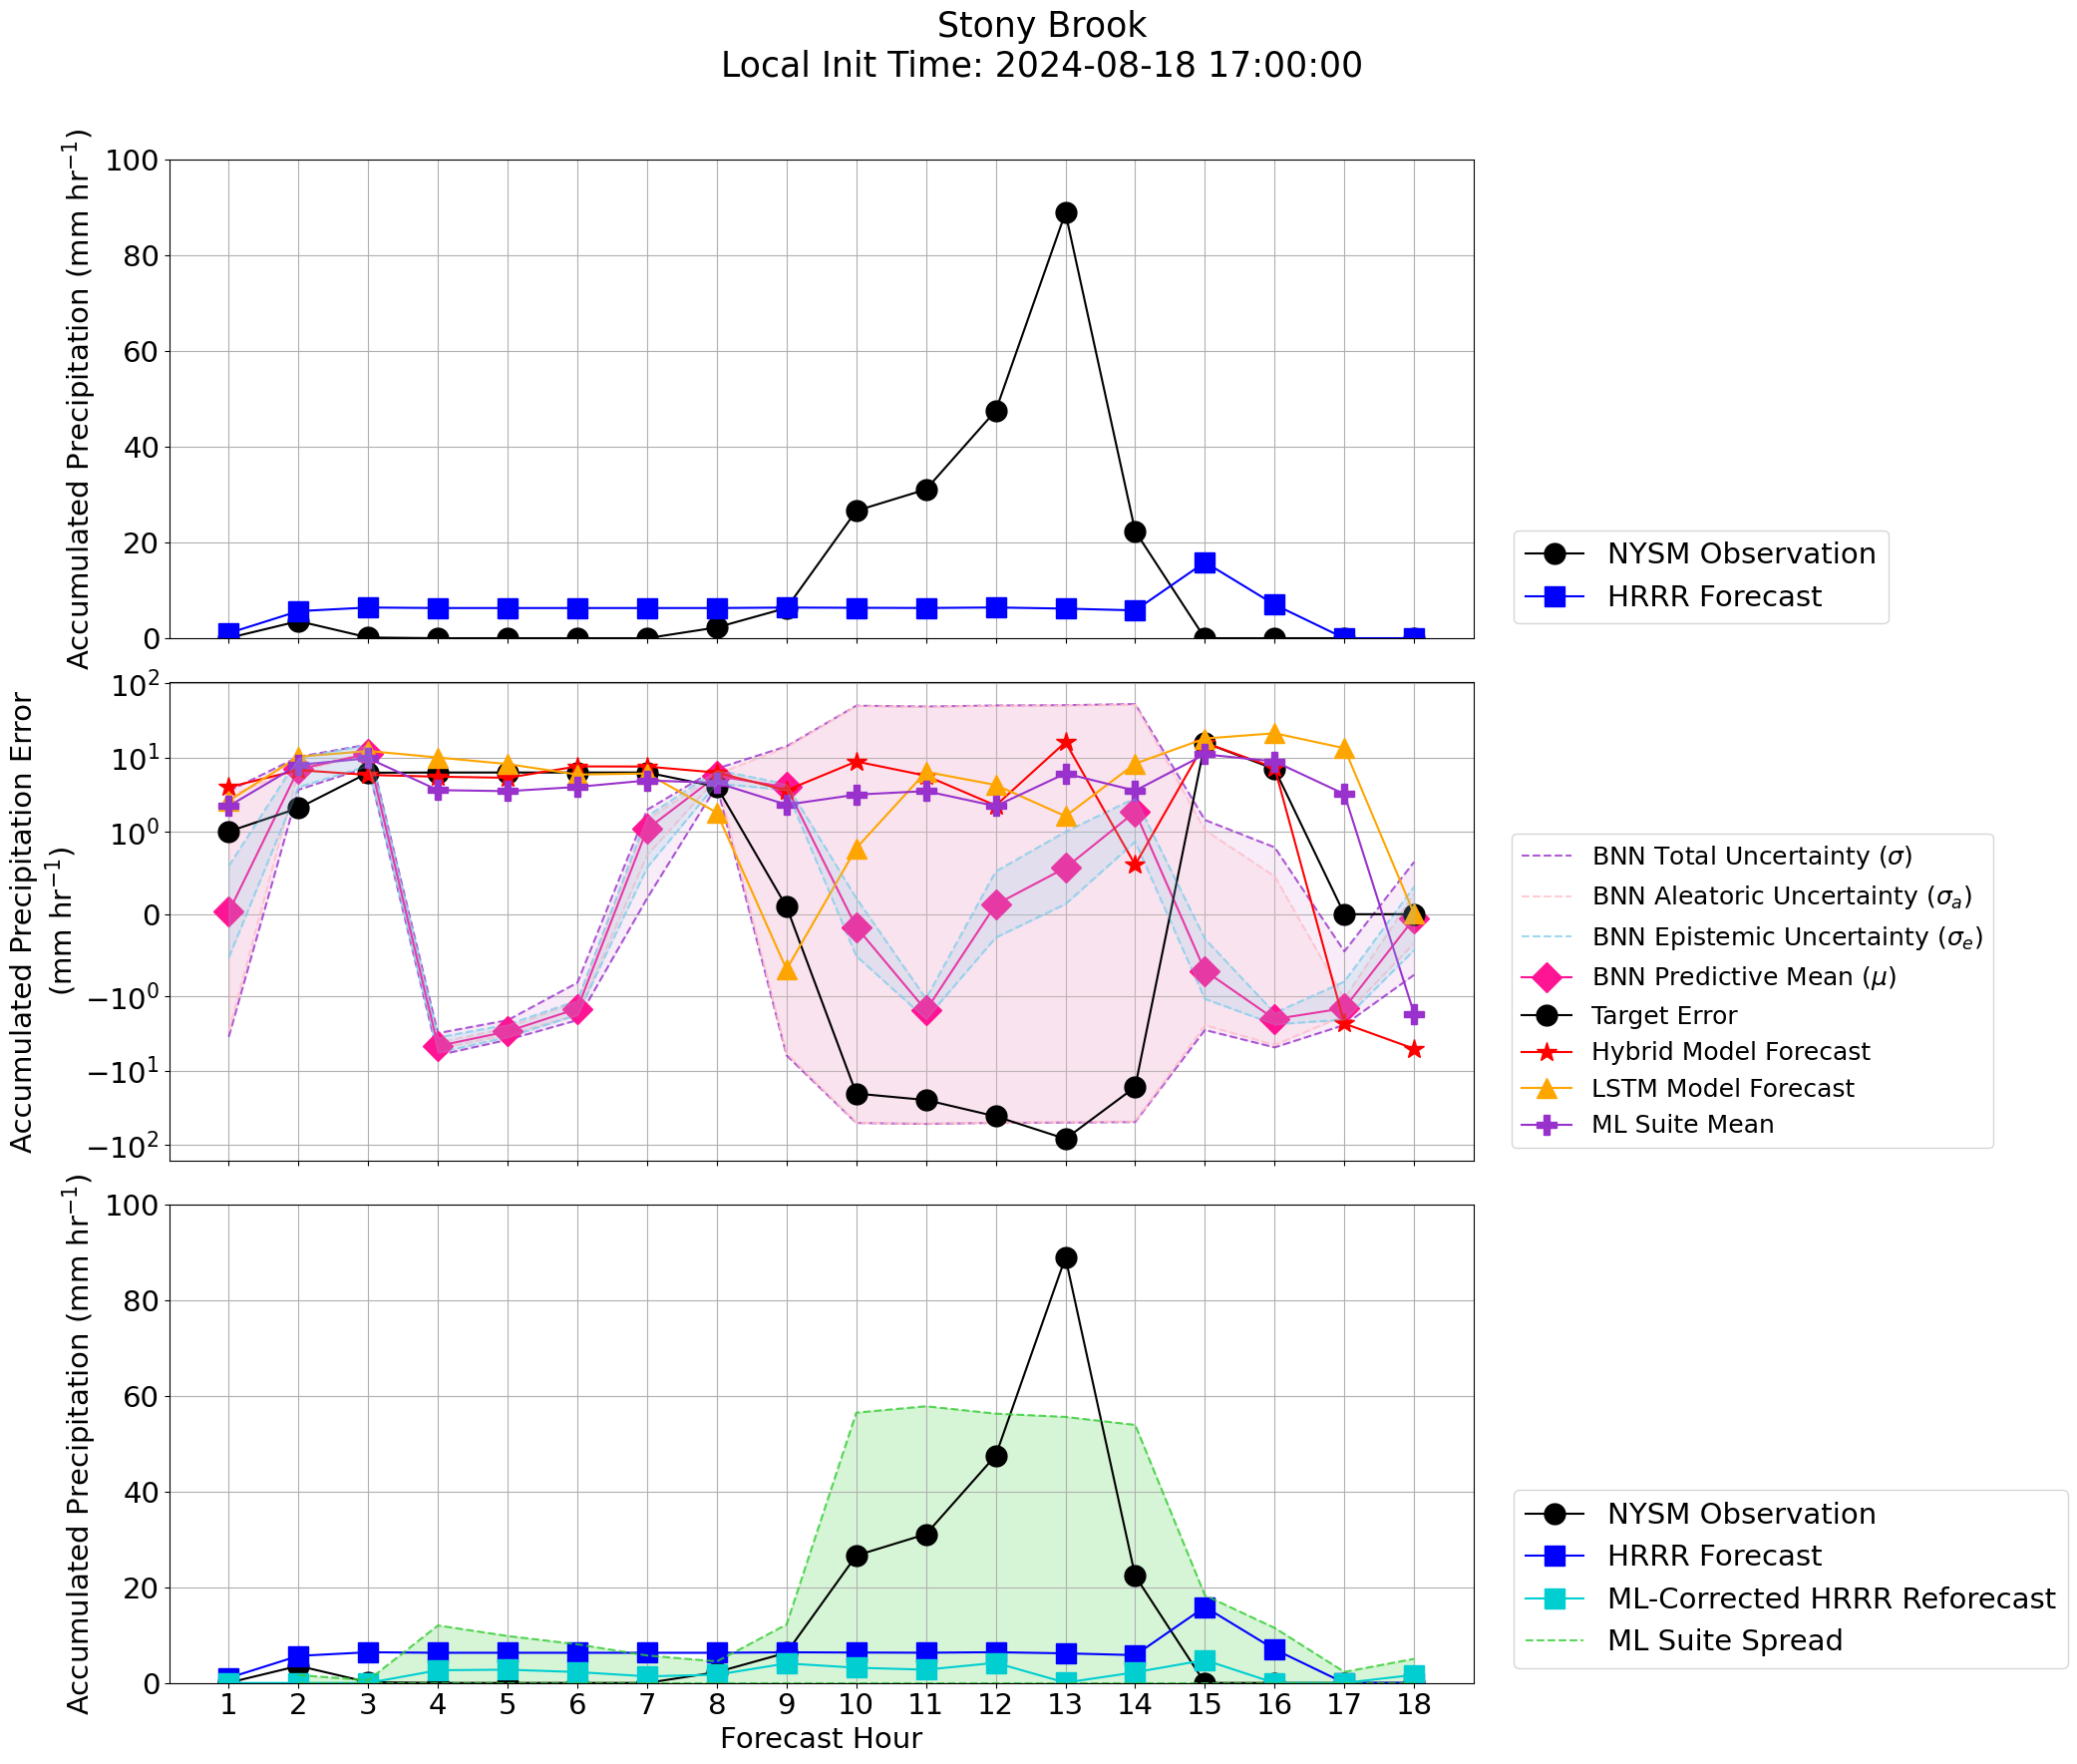

In [224]:
FONTSIZE = 21

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(21, 18), sharex=True)

valid_times = final_nysm_df["valid_time"].values
forecast_hours = np.arange(1, len(valid_times) + 1)

# =================================================
# Panel 1: NYSM vs HRRR precipitation
# =================================================
ax = axes[0]

ax.plot(
    final_nysm_df["valid_time"],
    final_nysm_df["precip_total"],
    marker="o",
    label="NYSM Observation",
    color="black",
    markersize=15,
)

ax.plot(
    final_hrrr_df["valid_time"],
    final_hrrr_df["tp"],
    marker="s",
    label="HRRR Forecast",
    color="blue",
    markersize=15,
)

ax.set_ylabel(
    r"Accumulated Precipitation (mm hr$^{-1}$)",
    fontsize=FONTSIZE,
)
# ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(0, 100)
ax.legend(
    fontsize=FONTSIZE,
    loc="lower left",
    bbox_to_anchor=(1.02, 0),
)
ax.grid(True)

# =================================================
# Panel 2: Error comparison
# =================================================
ax = axes[1]

final_bnn_df["e_q1"] = final_bnn_df["Model forecast"] + final_bnn_df["Model epi std"]
final_bnn_df["e_q3"] = final_bnn_df["Model forecast"] - final_bnn_df["Model epi std"]

final_bnn_df["a_q1"] = final_bnn_df["Model forecast"] + final_bnn_df["Model alea std"]
final_bnn_df["a_q3"] = final_bnn_df["Model forecast"] - final_bnn_df["Model alea std"]

final_bnn_df["c_q1"] = (
    final_bnn_df["Model forecast"]
    + final_bnn_df["Model epi std"]
    + final_bnn_df["Model alea std"]
)

final_bnn_df["c_q3"] = (
    final_bnn_df["Model forecast"]
    - final_bnn_df["Model epi std"]
    - final_bnn_df["Model alea std"]
)

ax.plot(
    final_bnn_df["valid_time"],
    final_bnn_df["c_q1"],
    linestyle="--",
    color="darkorchid",
    alpha=0.8,
    label=r"BNN Total Uncertainty ($\sigma$)",
)

ax.plot(
    final_bnn_df["valid_time"],
    final_bnn_df["c_q3"],
    linestyle="--",
    color="darkorchid",
    alpha=0.8,
)

ax.fill_between(
    final_bnn_df["valid_time"],
    final_bnn_df["c_q3"],
    final_bnn_df["c_q1"],
    color="plum",
    alpha=0.2,
    zorder=1,
)

ax.plot(
    final_bnn_df["valid_time"],
    final_bnn_df["a_q1"],
    linestyle="--",
    color="pink",
    alpha=0.8,
    label=r"BNN Aleatoric Uncertainty ($\sigma_a$)",
)

ax.plot(
    final_bnn_df["valid_time"],
    final_bnn_df["a_q3"],
    linestyle="--",
    color="pink",
    alpha=0.8,
)

ax.fill_between(
    final_bnn_df["valid_time"],
    final_bnn_df["a_q3"],
    final_bnn_df["a_q1"],
    color="pink",
    alpha=0.2,
    zorder=2,
)

ax.plot(
    final_bnn_df["valid_time"],
    final_bnn_df["e_q1"],
    linestyle="--",
    color="skyblue",
    alpha=0.8,
    label=r"BNN Epistemic Uncertainty ($\sigma_e$)",
)

ax.plot(
    final_bnn_df["valid_time"],
    final_bnn_df["e_q3"],
    linestyle="--",
    color="skyblue",
    alpha=0.8,
)

ax.fill_between(
    final_bnn_df["valid_time"],
    final_bnn_df["e_q3"],
    final_bnn_df["e_q1"],
    color="skyblue",
    zorder=3,
    alpha=0.2,
)

ax.plot(
    final_bnn_df["valid_time"],
    final_bnn_df["Model forecast"],
    marker="D",
    label=r"BNN Predictive Mean ($\mu$)",
    color="deeppink",
    markersize=15,
)

ax.plot(
    final_model_df["valid_time"],
    final_model_df["new_target"],
    marker="o",
    label="Target Error",
    color="black",
    markersize=15,
)

ax.plot(
    final_model_df["valid_time"],
    final_model_df["Model forecast"],
    marker="*",
    label="Hybrid Model Forecast",
    color="red",
    markersize=15,
)

ax.plot(
    final_lstm_df["valid_time"],
    final_lstm_df["Model forecast"],
    marker="^",
    label="LSTM Model Forecast",
    color="orange",
    markersize=15,
)

ax.plot(
    final_bnn_df["valid_time"],
    weighted_model.values,
    marker="P",
    label="ML Suite Mean",
    color="darkorchid",
    markersize=15,
)

ax.set_ylabel(
    r"Accumulated Precipitation Error" "\n" r"(mm hr$^{-1}$)",
    fontsize=FONTSIZE,
)

ax.set_yscale("symlog", linthresh=1)

ax.legend(
    fontsize=18,
    loc="lower left",
    bbox_to_anchor=(1.02, 0),
)

ax.grid(True)

# =================================================
# Panel 3: NYSM vs HRRR vs Reforecast
# =================================================
ax = axes[2]

bound_df = make_interval(
    formatted_times,
    final_model_df,
    final_lstm_df,
    final_bnn_df,
    final_bnn_df2,
    weighted_model,
    final_hrrr_df,
    hrrr_var,
)

bound_df["upper_bound"] = bound_df["upper_bound"].clip(lower=0)
bound_df["lower_bound"] = bound_df["lower_bound"].clip(lower=0)

ax.plot(
    final_nysm_df["valid_time"],
    final_nysm_df["precip_total"],
    marker="o",
    label="NYSM Observation",
    color="black",
    markersize=15,
)

ax.plot(
    final_hrrr_df["valid_time"],
    final_hrrr_df["tp"],
    marker="s",
    label="HRRR Forecast",
    color="blue",
    markersize=15,
)

ax.plot(
    final_hrrr_df["valid_time"],
    final_hrrr_df["reforecast"],
    marker="s",
    label="ML-Corrected HRRR Reforecast",
    color="darkturquoise",
    markersize=15,
)

ax.plot(
    bound_df["valid_time"],
    bound_df["upper_bound"],
    linestyle="--",
    color="limegreen",
    alpha=0.8,
    label="ML Suite Spread",
)

ax.plot(
    bound_df["valid_time"],
    bound_df["lower_bound"],
    linestyle="--",
    color="limegreen",
    alpha=0.8,
)

ax.fill_between(
    bound_df["valid_time"],
    bound_df["upper_bound"],
    bound_df["lower_bound"],
    color="limegreen",
    alpha=0.2,
)

ax.set_ylabel(
    r"Accumulated Precipitation (mm hr$^{-1}$)",
    fontsize=FONTSIZE,
)

# ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(0, 100)

ax.legend(
    fontsize=FONTSIZE,
    loc="lower left",
    bbox_to_anchor=(1.02, 0),
)

ax.grid(True)

# =================================================
# Shared x-axis formatting
# =================================================
axes[-1].set_xticks(valid_times)
axes[-1].set_xticklabels(forecast_hours, fontsize=FONTSIZE)
axes[-1].set_xlabel("Forecast Hour", fontsize=FONTSIZE)

for ax in axes:
    ax.tick_params(axis="y", labelsize=FONTSIZE)

fig.suptitle(
    f"Stony Brook\nLocal Init Time: {formatted_times[0]}",
    fontsize=FONTSIZE + 4,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [222]:
final_bnn_df

,target_error,Model forecast,Model alea std,Model epi std,valid_time,Model std,e_q1,e_q3,a_q1,a_q3,c_q1,c_q3
11551,1.026432,0.028409,0.459300,0.555481,2024-08-18 17:00:00,2.961976,0.583890,-0.527071,NaN,NaN,NaN,NaN
11481,2.160198,6.977567,58.992519,2.971540,2024-08-18 18:00:00,0.310048,9.949107,4.006027,7.287615,6.667519,10.259155,3.695979
11651,6.575130,11.273402,85.005989,3.509022,2024-08-18 19:00:00,0.299513,14.782424,7.764380,11.572915,10.973889,15.081937,7.464867
10300,6.781667,-4.637437,3.070295,1.076116,2024-08-18 20:00:00,0.453014,-3.561321,-5.713553,-4.184423,-5.090451,-3.108308,-6.166567
10909,6.601282,-2.948349,0.497550,0.565503,2024-08-18 21:00:00,0.304479,-2.382847,-3.513852,-2.643871,-3.252828,-2.078368,-3.818331
11654,6.753984,-1.452806,0.274261,0.318507,2024-08-18 22:00:00,0.303036,-1.134298,-1.771313,-1.149769,-1.755842,-0.831262,-2.074349
11655,6.905190,1.089550,0.785213,0.523836,2024-08-18 23:00:00,0.372077,1.613387,0.565714,1.461627,0.717474,1.985463,0.193638
11638,4.247601,5.657930,3.134850,1.149959,2024-08-19 00:00:00,0.323290,6.807890,4.507971,5.981221,5.334640,7.131180,4.184680
11657,0.100264,4.008040,0.453822,0.372884,2024-08-19 01:00:00,9.832222,4.380924,3.635156,13.840261,-5.824182,14.213146,-6.197065
11620,-21.287115,-0.155766,0.265795,0.351061,2024-08-19 02:00:00,50.000000,0.195295,-0.506827,49.844234,-50.155766,50.195297,-50.506828


In [223]:
final_bnn_df2

,target_error,Model forecast,Model std,valid_time
11649,1.026432,-0.262055,2.961976,2024-08-18 17:00:00
11481,2.160198,-0.002485,0.310048,2024-08-18 18:00:00
11651,6.575130,-0.003811,0.299513,2024-08-18 19:00:00
10300,6.781667,0.243253,0.453014,2024-08-18 20:00:00
10909,6.601282,-0.026306,0.304479,2024-08-18 21:00:00
11654,6.753984,-0.001502,0.303036,2024-08-18 22:00:00
11655,6.905190,-0.008070,0.372077,2024-08-18 23:00:00
11638,4.247601,-0.027220,0.323290,2024-08-19 00:00:00
11657,0.100264,-3.602324,9.832222,2024-08-19 01:00:00
11620,-21.287115,-10.976271,50.000000,2024-08-19 02:00:00


In [220]:
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr


def compute_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    r, _ = pearsonr(y_pred, y_true)
    return rmse, r2, r


# --------------------
# Collect models
# --------------------
models = {
    "HRRR": (
        final_nysm_df["wspd_sonic_mean"],
        final_hrrr_df["u_total"],
    ),
    "HRRR Reforecast": (
        final_nysm_df["wspd_sonic_mean"],
        final_hrrr_df["reforecast"],
    ),
    "Hybrid": (
        final_model_df["target_error"],
        final_model_df["Model forecast"],
    ),
    "LSTM": (
        final_lstm_df["target_error"],
        final_lstm_df["Model forecast"],
    ),
    "BNN": (
        final_bnn_df["target_error"],
        final_bnn_df["Model forecast"],
    ),
    "Weighted Ensemble": (
        final_model_df["target_error"],
        weighted_model,
    ),
}

# --------------------
# Compute + print
# --------------------
for name, (y_true, y_pred) in models.items():
    rmse, r2, r = compute_metrics(y_true, y_pred)
    print(f"{name:<18} | RMSE: {rmse:.3f} | R²: {r2:.3f} | r: {r:.3f}")

KeyError: 'wspd_sonic_mean'

# WeatherBench

In [ ]:
# stations = ['REDF', 'JORD']
# nysm_var = 'precip_total'
# hrrr_var = 'tp'
# time1 = datetime(2024, 11, 28, 0, 0, 0)
# time2 = datetime(2024, 12, 13, 23, 59, 59)

In [ ]:
# final_ls = []
# for station in stations:

#     # load nysm
#     nysm_df = nysm_data.load_nysm_data(gfs=False)

#     for fh in np.arange(1, 19):
#         print(fh)

#         # load hrrr
#         hrrr_df = hrrr_data.read_hrrr_data(str(fh).zfill(2))

#         # filter for station
#         nysm_ = nysm_df[nysm_df["station"] == station]
#         hrrr_ = hrrr_df[hrrr_df["station"] == station]

#         # filter for vars
#         nysm_ = nysm_[["valid_time", nysm_var]]
#         hrrr_ = hrrr_[["valid_time", hrrr_var]]

#         # filter for time
#         nysm_ = date_filter(nysm_, time1, time2)
#         hrrr_ = date_filter(hrrr_, time1, time2)

#         # compute target error df (HRRR - NYSM)
#         target_error_df = hrrr_.merge(nysm_, on="valid_time", how="left").fillna(0)
#         target_error_df["hrrr_error"] = target_error_df[hrrr_var] - target_error_df[nysm_var]

#         target_error = root_mean_squared_error(
#             target_error_df[hrrr_var], target_error_df[nysm_var]
#         )

#         # -----------------------
#         # LSTM (assumed exists)
#         # -----------------------
#         lstm_path = Path(
#             f"/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare/{station}/"
#             f"refitted_{station}_{hrrr_var}_{fh}_lstm_output.parquet"
#         )
#         lstm_df = pd.read_parquet(lstm_path)
#         lstm_df = date_filter(lstm_df, time1, time2)
#         lstm_error = root_mean_squared_error(lstm_df["Model forecast"], lstm_df["target_error"])

#         # -----------------------
#         # BNN (assumed exists)
#         # -----------------------
#         bnn_path = Path(
#             f"/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare/{station}/"
#             f"refitted_{station}_{hrrr_var}_{fh}_bnn_output.parquet"
#         )
#         bnn_df = pd.read_parquet(bnn_path)
#         bnn_df = date_filter(bnn_df, time1, time2)
#         bnn_error = root_mean_squared_error(bnn_df["Model forecast"], bnn_df["target_error"])

#         # -----------------------
#         # Hybrid (may NOT exist)
#         # -----------------------
#         hybrid_path = Path(
#             f"/home/aevans/nwp_bias/src/machine_learning/data/hybrid_output/{station}/"
#             f"refitted_{station}_fh{fh}_{hrrr_var}_HRRR_ml_output_og_hybrid.parquet"
#         )

#         hybrid_df = None
#         hybrid_error = np.nan

#         if hybrid_path.exists():
#             hybrid_df = pd.read_parquet(hybrid_path)
#             hybrid_df = date_filter(hybrid_df, time1, time2)
#             hybrid_error = root_mean_squared_error(hybrid_df["Model forecast"], hybrid_df["target_error"])

#         # -----------------------
#         # Combined ensemble (use what exists)
#         # -----------------------
#         model_series = [
#             lstm_df[["valid_time", "Model forecast"]].rename(columns={"Model forecast": "lstm"}),
#             bnn_df[["valid_time", "Model forecast"]].rename(columns={"Model forecast": "bnn"}),
#         ]
#         model_cols = ["lstm", "bnn"]

#         if hybrid_df is not None:
#             model_series.insert(
#                 0,
#                 hybrid_df[["valid_time", "Model forecast"]].rename(columns={"Model forecast": "hybrid"}),
#             )
#             model_cols.insert(0, "hybrid")

#         # Merge all model forecasts on valid_time (inner keeps only times present in all chosen models)
#         ensemble = model_series[0]
#         for df_add in model_series[1:]:
#             ensemble = ensemble.merge(df_add, on="valid_time", how="inner")

#         # Attach target error aligned by valid_time (NOT by index)
#         ensemble = ensemble.merge(
#             target_error_df[["valid_time", "hrrr_error"]],
#             on="valid_time",
#             how="inner",
#         ).rename(columns={"hrrr_error": "target_error"})

#         ensemble["combined"] = ensemble[model_cols].mean(axis=1)

#         ensemble_error = root_mean_squared_error(
#             ensemble["combined"], ensemble["target_error"]
#         )

#         # append
#         final_ls.append({
#             "station": station,
#             "fh": fh,
#             "hrrr": target_error,
#             "hybrid": hybrid_error,   # will be NaN if missing
#             "lstm": lstm_error,
#             "bnn": bnn_error,
#             "combined": ensemble_error,
#         })

# station_df = pd.DataFrame(final_ls).fillna(-999)

In [ ]:
# station_df

In [ ]:
# final_df = pd.DataFrame(
#     data=-999.0,
#     index=np.arange(1, 19),
#     columns=["hrrr", "lstm", "bnn", "hybrid", "combined"],
# )

# final_df.index.name = "fh"

In [ ]:
# hrrr = []
# lstm = []
# bnn = []
# hybrid = []
# combined = []

# for fh in np.arange(1, 19):
#     temp = station_df[station_df["fh"] == fh]

#     hrrr.append(temp["hrrr"].iloc[0])
#     lstm.append(temp["lstm"].iloc[0])
#     bnn.append(temp["bnn"].iloc[0])
#     hybrid.append(temp["hybrid"].iloc[0])
#     combined.append(temp["combined"].iloc[0])

# list_df = pd.DataFrame(
#     {
#         "hrrr": hrrr,
#         "lstm": lstm,
#         "bnn": bnn,
#         "hybrid": hybrid,
#         "combined": combined,
#     },
#     index=np.arange(1, 19),
# )

# list_df.index.name = "fh"

In [ ]:
# df1 = final_df.replace(-999, np.nan)
# df2 = list_df.replace(-999, np.nan)

In [ ]:
# final_df = pd.concat([df1, df2]).groupby(level=0).mean()
# final_df.fillna(-999, inplace = True)

In [ ]:
def weatherBench_raw(final_df, title, metric_label="RMSE"):
    FS = 14  # GLOBAL FONT SIZE

    df = final_df.replace(-999, np.nan).copy()

    # 1) HRRR absolute (top row)
    hrrr = df[["hrrr"]].T  # shape: (1, fh)

    # 2) Deltas for other models: model - hrrr (negative=better)
    other_cols = [c for c in df.columns if c != "hrrr"]
    deltas = df[other_cols].sub(df["hrrr"], axis=0).T

    # Color scaling
    hrrr_vmin = np.nanmin(hrrr.values)
    hrrr_vmax = np.nanmax(hrrr.values)

    max_abs_delta = np.nanmax(np.abs(deltas.values))
    delta_norm = TwoSlopeNorm(vmin=-max_abs_delta, vcenter=0.0, vmax=max_abs_delta)

    fig, (ax0, ax1) = plt.subplots(
        2,
        1,
        figsize=(21, 6),
        gridspec_kw={"height_ratios": [1, len(other_cols)], "hspace": 0.15},
        sharex=True,
    )

    # --- Top: HRRR absolute ---
    im0 = ax0.imshow(
        hrrr.values,
        aspect="auto",
        cmap="Greys",
        vmin=hrrr_vmin,
        vmax=hrrr_vmax,
    )
    ax0.set_yticks([0])
    ax0.set_yticklabels(["HRRR"], fontsize=FS)
    ax0.set_title(f"HRRR {metric_label}", fontsize=FS)

    cbar0 = fig.colorbar(im0, ax=ax0, fraction=0.03, pad=0.02)
    cbar0.set_label(metric_label, fontsize=FS)
    cbar0.ax.tick_params(labelsize=FS)

    # --- Bottom: deltas ---
    im1 = ax1.imshow(
        deltas.values,
        aspect="auto",
        cmap="RdBu_r",
        norm=delta_norm,
    )
    ax1.set_yticks(np.arange(len(other_cols)))
    ax1.set_yticklabels([c.upper() for c in other_cols], fontsize=FS)
    ax1.set_title(
        f"Δ{metric_label} vs HRRR",
        fontsize=FS,
    )

    cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.03, pad=0.02)
    cbar1.set_label(f"Δ{metric_label}", fontsize=FS)
    cbar1.ax.tick_params(labelsize=FS)

    # ----------------------------
    # Annotations (same fontsize)
    # ----------------------------
    FMT_ABS = "{:.2f}"
    FMT_DELTA = "{:+.2f}"

    def auto_text_color(rgba):
        r, g, b, _ = rgba
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        return "silver" if luminance < 0.5 else "black"

    # Top annotations
    for j in range(hrrr.shape[1]):
        val = hrrr.values[0, j]
        if np.isnan(val):
            continue
        rgba = im0.cmap(im0.norm(val))
        ax0.text(
            j,
            0,
            FMT_ABS.format(val),
            ha="center",
            va="center",
            fontsize=FS,
            color=auto_text_color(rgba),
        )

    # Bottom annotations
    for i in range(deltas.shape[0]):
        for j in range(deltas.shape[1]):
            val = deltas.values[i, j]
            if np.isnan(val):
                continue
            rgba = im1.cmap(im1.norm(val))
            ax1.text(
                j,
                i,
                FMT_DELTA.format(val),
                ha="center",
                va="center",
                fontsize=FS,
                color=auto_text_color(rgba),
            )

    # X axis
    fhs = df.index.to_numpy()
    ax1.set_xticks(np.arange(len(fhs)))
    ax1.set_xticklabels(fhs, fontsize=FS)
    ax1.set_xlabel("Forecast Hour", fontsize=FS)

    # Suptitle
    fig.suptitle(title, fontsize=int(FS + 4), y=0.98)

    plt.tight_layout()
    plt.show()

In [ ]:
def weatherBench_percent(final_df, title, metric_label="RMSE"):
    FS = 14  # GLOBAL FONT SIZE

    df = final_df.replace(-999, np.nan).copy()

    # 1) HRRR absolute (top row)
    hrrr = df[["hrrr"]].T  # shape: (1, fh)

    # 2) Percent improvement for other models:
    #    100 * (HRRR - model) / HRRR  -> positive = better
    other_cols = [c for c in df.columns if c != "hrrr"]

    # Guard against divide-by-zero
    denom = df["hrrr"].where(df["hrrr"] != 0, np.nan)

    pct = df[other_cols].rsub(df["hrrr"], axis=0).div(denom, axis=0).mul(100.0).T

    # Color scaling (symmetric)
    max_abs_pct = np.nanmax(np.abs(pct.values))
    pct_norm = TwoSlopeNorm(vmin=-max_abs_pct, vcenter=0.0, vmax=max_abs_pct)

    # HRRR scaling
    hrrr_vmin = np.nanmin(hrrr.values)
    hrrr_vmax = np.nanmax(hrrr.values)

    fig, (ax0, ax1) = plt.subplots(
        2,
        1,
        figsize=(21, 6),
        gridspec_kw={"height_ratios": [1, len(other_cols)], "hspace": 0.15},
        sharex=True,
    )

    # --- Top: HRRR absolute ---
    im0 = ax0.imshow(
        hrrr.values,
        aspect="auto",
        cmap="Greys",
        vmin=hrrr_vmin,
        vmax=hrrr_vmax,
    )
    ax0.set_yticks([0])
    ax0.set_yticklabels(["HRRR"], fontsize=FS)
    ax0.set_title(f"HRRR {metric_label}", fontsize=FS)

    cbar0 = fig.colorbar(im0, ax=ax0, fraction=0.03, pad=0.02)
    cbar0.set_label(metric_label, fontsize=FS)
    cbar0.ax.tick_params(labelsize=FS)

    # --- Bottom: percent improvement ---
    im1 = ax1.imshow(
        pct.values,
        aspect="auto",
        cmap="RdBu",
        norm=pct_norm,
    )
    ax1.set_yticks(np.arange(len(other_cols)))
    ax1.set_yticklabels([c.upper() for c in other_cols], fontsize=FS)
    ax1.set_title(
        "% improvement vs HRRR",
        fontsize=FS,
    )

    cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.03, pad=0.02)
    cbar1.set_label("% improvement", fontsize=FS)
    cbar1.ax.tick_params(labelsize=FS)

    # ----------------------------
    # Annotations (same fontsize)
    # ----------------------------
    FMT_ABS = "{:.2f}"
    FMT_PCT = "{:+.1f}%"

    def auto_text_color(rgba):
        r, g, b, _ = rgba
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        return "silver" if luminance < 0.5 else "black"

    # Top annotations
    for j in range(hrrr.shape[1]):
        val = hrrr.values[0, j]
        if np.isnan(val):
            continue
        rgba = im0.cmap(im0.norm(val))
        ax0.text(
            j,
            0,
            FMT_ABS.format(val),
            ha="center",
            va="center",
            fontsize=FS,
            color=auto_text_color(rgba),
        )

    # Bottom annotations
    for i in range(pct.shape[0]):
        for j in range(pct.shape[1]):
            val = pct.values[i, j]
            if np.isnan(val):
                continue
            rgba = im1.cmap(im1.norm(val))
            ax1.text(
                j,
                i,
                FMT_PCT.format(val),
                ha="center",
                va="center",
                fontsize=FS,
                color=auto_text_color(rgba),
            )

    # X axis
    fhs = df.index.to_numpy()
    ax1.set_xticks(np.arange(len(fhs)))
    ax1.set_xticklabels(fhs, fontsize=FS)
    ax1.set_xlabel("Forecast Hour", fontsize=FS)

    # Suptitle
    fig.suptitle(title, fontsize=int(FS + 4), y=0.98)

    plt.tight_layout()
    plt.show()

In [ ]:
# weatherBench_raw(final_df, "Practice")

In [ ]:
# weatherBench_percent(final_df, "Practice")